# 손 X-ray 골연령 예측 — **Xception 회귀 / 정규화 → Top-Hat → CLAHE → 레터박스**

> Zhang, Wu, Zhou & Li, *Uncertainty-aware multi-stream deep learning for pediatric bone age assessment* (JKSU-CIS, 2026)
> 이전 노트북(정규화 → CLAHE)에 **Top-Hat 형태학 필터**를 한 단계 추가한 버전입니다.

## 입력 전제
`BASE_DIR/전처리/{train,validation,test}` 의 이미지는 **직접 학습시킨 bbox 검출 모델로 손 영역을 이미 크롭한 결과**입니다.
이 노트북은 크롭을 다시 하지 않습니다.

## 전처리 5단계

```
① 밝기 정규화 (백분위 스트레치)
   → ② Top-Hat (연조직 배경 제거·골 구조 강조)   ← 이번에 추가
      → ③ CLAHE (국소 대비)
         → ④ 비율 유지 리사이즈  → ⑤ 배경색 패딩 → 512×512
```

| 단계 | 역할 |
|---|---|
| ① 정규화 | 크롭 샘플 실측: 한 장은 픽셀값 39~79(유효 40레벨), 다른 장은 91~251(161레벨). 정규화 없이는 두 장의 대비가 2.7배 어긋난 채 입력됩니다 |
| **② Top-Hat** | **커널보다 작은 밝은 구조만 남기는 연산.** 손등 두께·연조직 음영 같은 완만한 밝기 변화를 빼내어, CLAHE가 조명 얼룩 대신 골 구조에 반응하게 만듭니다 |
| ③ CLAHE | 골단판·피질골 경계의 국소 대비 강화 |
| ④ 리사이즈 | 배율 하나를 양축에 곱하므로 종횡비 보존 (1.44 → 1.44) |
| ⑤ 패딩 | 여백을 배경색 추정치로 채워 인공 엣지 방지 |

## Top-Hat 파라미터 — 실측 근거

**커널은 뼈보다 커야 합니다.** 커널보다 큰 밝은 덩어리는 배경으로 간주되어 제거되므로,
커널이 뼈 굵기보다 작으면 굵은 뼈 내부가 파이고 윤곽만 남습니다.

| 측정 항목 | 값 |
|---|---|
| 중수골 밝은 구간 폭 (스캔라인 실측) | 4361: 최대 84px · 4362: 최대 88px |
| 기본 `TOPHAT_KFRAC = 0.10` | 긴 변 1252 → **k = 125px** (뼈 폭보다 여유 있게 큼) |

**커널 모양은 사각형(`rect`)이 기본입니다.** OpenCV는 사각 커널만 1D 분리 연산으로 처리합니다.

| k=125 | 속도 | 12,611장 환산 |
|---|---|---|
| `rect` | **5.8 ms/장** | 약 1분 |
| `ellipse` | 379 ms/장 | 약 80분 |

두 결과의 상관계수는 **0.9898** — 65배 느린 값을 치를 이유가 없습니다.

## 저장 위치 (이전 노트북과 완전 분리)
- 캐시: `BASE_DIR/cache_tophat_pipeline/<설정태그>/`
- 체크포인트: `BASE_DIR/checkpoints_xception_tophat/` (`best.pt` · `last.pt` · `history.json`)

## 모델 (논문 §3.4 식 13~17)
$$\mathbf{z}=\mathrm{Flat}\big(\mathrm{MaxPool}_{3\times3}(\mathrm{Conv}_{3\times3}(\mathbf{F}))\big),\qquad
\mathbf{e}=\phi_\psi(g)\in\mathbb{R}^{32},\qquad
\hat{y}=\mathbf{w}^\top[\mathbf{z};\mathbf{e}]+b$$

## 실행 순서
`PART 0` (전부) → `PART 1` (전처리 캐시 1회) → `PART 2` → `PART 3` (학습) → `PART 4` (평가)


---
# PART 0 · 공통 셋업  *(항상 먼저 실행 — 전부 정의/로드, 무거운 연산 없음)*

### 0-1. 환경 확인

In [1]:
import os, sys, json, math, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from tqdm.auto import tqdm

# Xception은 torchvision에 없습니다 -> timm 필요 (최초 1회만 설치)
# !pip install timm
import timm

print("Python     :", sys.version.split()[0])
print("PyTorch    :", torch.__version__)
print("torchvision:", torchvision.__version__)
print("timm       :", timm.__version__)
print("OpenCV     :", cv2.__version__)
print("CUDA avail :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU        :", torch.cuda.get_device_name(0), "| CUDA", torch.version.cuda)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device     :", device)

# [주의] RTX 5060(Blackwell, sm_120)은 최신 PyTorch 필요.
# CUDA=False 이거나 'no kernel image' 오류 시 CUDA 12.8+ 빌드 설치:
#   pip install --pre torch torchvision --index-url https://download.pytorch.org/whl/nightly/cu128

Python     : 3.11.9
PyTorch    : 2.12.0.dev20260408+cu128
torchvision: 0.27.0.dev20260407+cu128
timm       : 1.0.28
OpenCV     : 4.10.0
CUDA avail : True
GPU        : NVIDIA GeForce RTX 5060 Laptop GPU | CUDA 12.8
device     : cuda


### 0-2. 시드 & 한글 경로 로더
`cv2.imread/imwrite`는 경로에 한글이 있으면 **조용히 실패**합니다 → `np.fromfile + imdecode` 조합을 씁니다.

In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

def imread_kr(path, flags=cv2.IMREAD_GRAYSCALE):
    '''한글/유니코드 경로에서도 동작하는 이미지 로드. 실패 시 None.'''
    try:
        data = np.fromfile(str(path), dtype=np.uint8)
        return cv2.imdecode(data, flags)
    except Exception:
        return None

def imwrite_kr(path, img):
    '''한글/유니코드 경로에도 저장 가능한 이미지 쓰기.'''
    path = str(path); ext = os.path.splitext(path)[1] or ".png"
    ok, buf = cv2.imencode(ext, img)
    if ok: buf.tofile(path)
    return ok

def torch_load(path, map_location=None):
    '''PyTorch 2.6+ 는 weights_only 기본값이 True -> arch 딕셔너리 로드가 막힙니다.'''
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:                       # 구버전 PyTorch 호환
        return torch.load(path, map_location=map_location)

print("시드 고정 완료 · 한글 경로 로더 준비 완료")

시드 고정 완료 · 한글 경로 로더 준비 완료


### 0-3. 경로 설정 & 전처리 파라미터
**`BASE_DIR` 한 줄만** 본인 경로로 수정하세요. 캐시·체크포인트 폴더는 이전 노트북과 **분리**되어 있습니다.

In [3]:
# ── 경로: 여기만 수정 ───────────────────────────────────────────────
BASE_DIR = Path(r"C:\Users\Win11Pro\Desktop\뼈데이터")   # ← 수정

TRAIN_IMG_DIR = BASE_DIR / "전처리" / "train"
TRAIN_CSV     = BASE_DIR / "Bone+Age+Training+Set+Annotations" / "train.csv"
VAL_IMG_DIR   = BASE_DIR / "전처리" / "validation"
VAL_CSV       = BASE_DIR / "Bone+Age+Validation+Set" / "Bone Age Validation Set" / "Validation Dataset.csv"

# ── test 세트 (★ 실제 폴더/CSV 이름에 맞게 수정) ──────────────────────
TEST_IMG_DIR  = BASE_DIR / "전처리" / "test"
TEST_CSV      = BASE_DIR / "Bone+Age+Test+Set" / "Bone age ground truth.csv"

# ══ 전처리 설정 ═══════════════════════════════════════════════════
# 입력은 이미 bbox 모델로 손을 크롭한 이미지. 여기서 크롭은 하지 않습니다.
IMG_SIZE     = 512        # 최종 정사각 캔버스 크기

# ① 밝기 정규화 ─────────────────────────────────────────────────────
NORM_MODE    = "percentile"  # "percentile" | "minmax" | "none"
NORM_LO, NORM_HI = 1.0, 99.0 # 백분위 하한/상한 (마커·핫픽셀 클리핑)

# ② Top-Hat ★신규 ─────────────────────────────────────────────────
#   White Top-Hat = 원본 − Opening(원본).  커널보다 "작은 밝은 구조"만 남습니다.
#   연조직 두께 차이 같은 완만한 배경 밝기를 제거해 CLAHE가 골 구조에 집중하게 합니다.
TOPHAT_MODE   = "add"     # "none"   : 사용 안 함 (이전 노트북과 동일)
                          # "white"  : Top-Hat 결과만 사용 (배경 완전 제거, 조직 밝기 정보 소실)
                          # "add"    : 원본 + w·TopHat        (배경 유지 + 골 강조, 권장)
                          # "addsub" : 원본 + w·TopHat − w·BlackHat (밝은·어두운 구조 동시 강조)
TOPHAT_KFRAC  = 0.10      # 커널 크기 = 긴 변 × KFRAC.  원본 해상도가 제각각이라 상대 지정.
                          # ★ 커널은 뼈 굵기보다 커야 합니다. 실측 중수골 폭 84~88px,
                          #    긴 변 1252 기준 0.10 -> 125px 로 여유 확보.
                          #    0.06(75px) 이하로 내리면 굵은 뼈 내부가 파입니다.
TOPHAT_KSIZE  = 0         # >0 이면 절대 픽셀 크기로 고정 (KFRAC 무시)
TOPHAT_SHAPE  = "rect"    # "rect"(기본) | "ellipse" | "cross"
                          # ★ rect는 1D 분리 연산이라 k=125에서 5.8ms, ellipse는 379ms (65배).
                          #    두 결과 상관계수 0.99 — 특별한 이유가 없으면 rect.
TOPHAT_WEIGHT = 1.0       # add / addsub 에서 가산 강도 (0.5 = 절반만 섞음)

# ③ CLAHE ──────────────────────────────────────────────────────────
CLAHE_CLIP   = 2.0        # clipLimit (대비 증폭 상한)
CLAHE_TILE   = 8          # tileGridSize -> 8x8 타일

# ④ 배율 정책 ──────────────────────────────────────────────────────
SCALE_MODE   = "per_image"  # "per_image": 각 이미지 긴 변을 IMG_SIZE에 맞춤 (해상도 최대 활용)
                            # "global"   : 데이터셋 공통 배율 (손의 절대 크기 보존)
GLOBAL_REF_PCTL = 99.0      # "global"일 때 기준 긴 변의 백분위

# ⑤ 패딩 ───────────────────────────────────────────────────────────
PAD_MODE     = "auto"     # "auto"(테두리 하위 백분위) | "zero" | "replicate" | 정수
PAD_BORDER_FRAC = 0.02    # 배경 추정에 쓸 테두리 두께 (짧은 변의 2%)
PAD_BORDER_PCTL = 25.0    # 테두리 링에서 취할 백분위 (중앙값=50 대신 하위값으로 안전하게)
PAD_ANCHOR   = "center"   # "center" | "topleft"

USE_AUG      = False      # 논문 미언급. 재현 기준선은 False
# ══════════════════════════════════════════════════════════════════

# ── 이상 이미지 제외 스위치 ────────────────────────────────────────
# True 로 바꾸면 아래 목록이 train/val/test 전부에서 제외됩니다.
USE_EXCLUDE_IDS = True
EXCLUDE_IDS = {
    "1405", "1430", "1431", "1521", "1545", "1599", "1607", "1779", "1799", "1826", 
    "1840", "1863", "1926", "1973", "2133", "2193", "2213", "2256", "2296", "2372", 
    "2414", "2505", "2662", "2687", "2823", "2848", "2934", "3079", "3100", "3110", 
    "3156", "3157", "3387", "3475", "3528", "3655", "3722", "3736", "3752", "3823", 
    "3880", "3883", "3884", "3885", "3899", "3219", "3905", "3931", "3964", "3998", 
    "3999", "4004", "4067", "4071", "4128", "4193", "4210", "4217", "4230", "4243", 
    "4284", "4792", "6232", "6293", "6484", "6573", "6784", "6886", "7048", "7179", 
    "7235", "7358", "7491", "7507", "7555", "7758", "7784", "7822", "7826", "7840", 
    "7884", "7893", "7963", "7979", "8124", "8142", "8451", "8566", "8599", "8607", 
    "8623", "8680", "8821", "8836", "9024", "9194", "9401", "9728", "10059", "10087", 
    "10278", "10573", "10715", "10720", "11043", "11079", "11152", "11367", "11863", 
    "11910", "11917", "11971", "11987", "12036", "12074", "12192", "12296", "12335", 
    "12351", "12684", "13130", "14011", "14086", "14152", "14179", "14234", "14235", 
    "14281", "14343", "14552", "14595", "14742", "14770", "15035", "15114", "15234", 
    "15398", "15413",
    "1397", "1450", "1537", "1583", "1687", "1740", "2190", "2945", "3131", "3319", 
    "3326", "3404", "3625", "3853", "3868", "4022", "4119", "4274", "4800", "5618", 
    "6165", "6393", "7629", "7790", "8549", "9607", "10389", "10543", "11146", "11183", 
    "11312", "11559", "11774", "11839", "12110", "13308", "13806", "14325", "14746",
    "4389", "4423", "4432", "4455", "4483"
    }

# 캐시/체크포인트: Top-Hat 설정까지 태그에 포함 -> 이전 실험과 절대 섞이지 않습니다.
_NORM_TAG = "none" if NORM_MODE == "none" else (
    "mm" if NORM_MODE == "minmax" else f"p{NORM_LO:g}-{NORM_HI:g}")
_TH_TAG   = "off" if TOPHAT_MODE == "none" else (
    f"{TOPHAT_MODE}-{TOPHAT_SHAPE}-" +
    (f"k{TOPHAT_KSIZE}" if TOPHAT_KSIZE > 0 else f"f{TOPHAT_KFRAC:g}") +
    f"-w{TOPHAT_WEIGHT:g}")
_SC_TAG   = "img" if SCALE_MODE == "per_image" else f"glob{GLOBAL_REF_PCTL:g}"
PRE_TAG   = (f"crop_{IMG_SIZE}_n{_NORM_TAG}_th{_TH_TAG}"
             f"_c{CLAHE_CLIP:g}t{CLAHE_TILE}_{_SC_TAG}_pad{PAD_MODE}")
CACHE_DIR = BASE_DIR / "cache_tophat_pipeline" / PRE_TAG
CKPT_DIR  = BASE_DIR / "checkpoints_xception_tophat"
for d in (CACHE_DIR, CACHE_DIR/"train", CACHE_DIR/"val", CACHE_DIR/"test", CKPT_DIR):
    d.mkdir(parents=True, exist_ok=True)

BEST_CKPT    = CKPT_DIR / "best.pt"          # 배포/추론용(자체완결)
LAST_CKPT    = CKPT_DIR / "last.pt"          # 재개용(옵티마이저 포함)
HISTORY_JSON = CKPT_DIR / "history.json"
DONE_MARKER  = CACHE_DIR / "_DONE.json"
REF_JSON     = CACHE_DIR / "_REF_LONG.json"  # SCALE_MODE="global"의 기준 긴 변 캐시

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(f"BASE_DIR : {BASE_DIR}")
print(f"전처리   : norm({NORM_MODE}) -> tophat({TOPHAT_MODE},{TOPHAT_SHAPE},"
      f"{'k'+str(TOPHAT_KSIZE) if TOPHAT_KSIZE>0 else 'frac'+str(TOPHAT_KFRAC)}) "
      f"-> CLAHE({CLAHE_CLIP},{CLAHE_TILE}) -> scale({SCALE_MODE}) -> pad({PAD_MODE}) -> {IMG_SIZE}px")
print(f"제외목록 : {'적용 ('+str(len(EXCLUDE_IDS))+'장)' if USE_EXCLUDE_IDS else '미적용(전량 사용)'}")
print(f"CACHE    : {CACHE_DIR}")
print(f"CKPT     : {CKPT_DIR}")

BASE_DIR : C:\Users\Win11Pro\Desktop\뼈데이터
전처리   : norm(percentile) -> tophat(add,rect,frac0.1) -> CLAHE(2.0,8) -> scale(per_image) -> pad(auto) -> 512px
제외목록 : 적용 (182장)
CACHE    : C:\Users\Win11Pro\Desktop\뼈데이터\cache_tophat_pipeline\crop_512_np1-99_thadd-rect-f0.1-w1_c2t8_img_padauto
CKPT     : C:\Users\Win11Pro\Desktop\뼈데이터\checkpoints_xception_tophat


### 0-4. 라벨 로드 (CSV) & 타깃 통계

In [4]:
def load_labels(csv_path, img_dir):
    '''id/boneage/male 컬럼을 유연하게 탐지해 표준 DataFrame으로 반환.'''
    df = pd.read_csv(csv_path)
    cols = {c.lower().strip(): c for c in df.columns}
    def pick(keys):
        for k in keys:
            for lc, orig in cols.items():
                if k in lc: return orig
        return None
    id_col  = pick(["id", "case", "image"]) or df.columns[0]
    age_col = pick(["boneage", "bone age", "age"])
    sex_col = pick(["male", "sex", "gender"])
    assert age_col and sex_col, f"컬럼 탐지 실패: {list(df.columns)}"
    out = pd.DataFrame()
    out["id"]      = df[id_col].astype(str).str.replace(".png","",regex=False).str.strip()
    out["boneage"] = pd.to_numeric(df[age_col], errors="coerce")
    s = df[sex_col]
    if s.dtype == bool:
        male = s.astype(int)
    else:
        sv = s.astype(str).str.lower().str.strip()
        male = sv.map({"true":1,"false":0,"m":1,"f":0,"male":1,"female":0,"1":1,"0":0})
        if male.isna().any(): male = pd.to_numeric(s, errors="coerce")
    out["male"] = male.astype(float)
    out["path"] = out["id"].apply(lambda i: str(Path(img_dir)/f"{i}.png"))
    return out.dropna(subset=["boneage","male"]).reset_index(drop=True)

train_df = load_labels(TRAIN_CSV, TRAIN_IMG_DIR)
val_df   = load_labels(VAL_CSV,   VAL_IMG_DIR)

# test 세트 로드 (경로가 있으면). 없으면 빈 DF로 두고 안내만.
HAS_TEST = TEST_CSV.exists() and TEST_IMG_DIR.exists()
if HAS_TEST:
    test_df = load_labels(TEST_CSV, TEST_IMG_DIR)
else:
    test_df = pd.DataFrame(columns=["id","boneage","male","path"])
    print("⚠ test 세트를 찾지 못했습니다 → 셀 0-3의 TEST_IMG_DIR / TEST_CSV 경로를 확인하세요.")
    print("   IMG:", TEST_IMG_DIR); print("   CSV:", TEST_CSV)

# ── 이상 이미지 제외 (스위치가 켜져 있을 때만) ──
def drop_excluded(df, name):
    if not USE_EXCLUDE_IDS or not len(df): return df
    before = len(df)
    df = df[~df["id"].isin(EXCLUDE_IDS)].reset_index(drop=True)
    if before - len(df):
        print(f"  · {name}: 이상 이미지 {before-len(df)}장 제외")
    return df
train_df = drop_excluded(train_df, "train")
val_df   = drop_excluded(val_df,   "val")
test_df  = drop_excluded(test_df,  "test")

AGE_MEAN = float(train_df.boneage.mean())     # 회귀 안정화용(가정): 학습셋 통계
AGE_STD  = float(train_df.boneage.std())
print(f"학습 {len(train_df):,} · 검증 {len(val_df):,} · 테스트 {len(test_df):,} "
      f"| 나이 {AGE_MEAN:.2f}±{AGE_STD:.2f} | 남 {train_df.male.mean():.1%}")

  · train: 이상 이미지 138장 제외
  · val: 이상 이미지 39장 제외
  · test: 이상 이미지 5장 제외
학습 12,473 · 검증 1,386 · 테스트 195 | 나이 127.58±40.85 | 남 54.2%


### 0-5. 전처리 함수 — 정규화 → **Top-Hat** → CLAHE → 리사이즈 → 패딩

| 단계 | 함수 | 핵심 |
|---|---|---|
| ① 정규화 | `normalize_intensity` | 백분위 [1%, 99%]를 0~255로 스트레치 |
| ② **Top-Hat** | `apply_tophat` | `원본 − Opening(원본)`. 커널보다 작은 밝은 구조만 남김 |
| ③ CLAHE | `apply_clahe` | 타일별 대비 제한 평활화 |
| ④ 배율 | `compute_scale` | `per_image` = 긴 변 → 512 · `global` = 공통 배율 |
| ⑤ 리사이즈+패딩 | `fit_canvas` | 축소 후 여백을 배경색으로 채움 |

**Top-Hat이 하는 일**
`Opening`(침식 후 팽창)은 커널보다 작은 밝은 구조를 지워버립니다. 그래서 `Opening` 결과는
"완만한 배경 밝기 지도"가 되고, 원본에서 이걸 빼면 **국소적으로 튀는 밝은 구조 = 골 구조**만 남습니다.
손등 두께에 따른 연조직 음영, X선 조사량 불균일 같은 저주파 성분이 제거되므로,
뒤따르는 CLAHE가 조명 얼룩 대신 골단판·피질골 경계에 반응하게 됩니다.

**커널 크기가 이 단계의 전부입니다**
커널보다 **큰** 밝은 덩어리는 "배경"으로 간주되어 제거됩니다. 커널이 뼈 굵기보다 작으면
굵은 중수골 내부가 파여서 윤곽선만 남는 결과가 나옵니다. 실측 중수골 폭이 84~88px이므로
`TOPHAT_KFRAC = 0.10`(긴 변 1252 → 125px)이 안전선입니다. QC 셀에서 이 값을 반드시 눈으로 확인하세요.

**모드 선택**
- `"add"` (기본): `원본 + Top-Hat`. 연조직 밝기 정보를 유지한 채 골 구조만 밝게 올립니다. 정보 손실이 없어 가장 무난합니다.
- `"white"`: Top-Hat 결과만 사용. 배경이 거의 검게 죽습니다. 골 형태에 집중시키지만 조직 밀도 정보를 버립니다.
- `"addsub"`: `원본 + TopHat − BlackHat`. 밝은 구조는 더 밝게, 어두운 틈(골단판 간극)은 더 어둡게. 대비가 가장 강하지만 노이즈도 함께 증폭됩니다.
- `"none"`: 이 단계를 끄고 이전 노트북과 동일하게 동작 — **Top-Hat 효과를 단독 측정하는 대조군**입니다.

**커널 모양**
`rect`는 1D 분리 연산으로 처리되어 `ellipse`보다 65배 빠릅니다(k=125에서 5.8ms vs 379ms).
두 결과의 상관계수는 0.99라 실질 차이가 없으므로 기본값은 `rect`입니다.


In [5]:
# ══════════════════════════════════════════════════════════════════
#  전처리:  ① 정규화 → ② CLAHE → ③ 배율 → ④ 리사이즈+패딩
#  (입력은 이미 bbox 크롭된 이미지 — 여기서 크롭은 하지 않습니다)
# ══════════════════════════════════════════════════════════════════
def _to_uint8(g):
    """16bit·float 입력도 안전하게 8bit로."""
    if g.dtype == np.uint8:
        return g
    g = g.astype(np.float32)
    lo, hi = float(g.min()), float(g.max())
    if hi - lo < 1e-6:
        return np.zeros(g.shape, np.uint8)
    return np.clip((g - lo) / (hi - lo) * 255.0, 0, 255).astype(np.uint8)


# ── ① 밝기 정규화 ──────────────────────────────────────────────────
def normalize_intensity(g, mode=None, lo=None, hi=None):
    """이미지 간 밝기·계조 편차 제거. CLAHE보다 반드시 앞에 옵니다.
       percentile: [lo%, hi%] 구간을 0~255로 선형 스트레치 (구간 밖은 클리핑)."""
    mode = NORM_MODE if mode is None else mode
    lo   = NORM_LO   if lo   is None else lo
    hi   = NORM_HI   if hi   is None else hi
    g = _to_uint8(g)
    if mode == "none":
        return g
    if mode == "minmax":
        a, b = float(g.min()), float(g.max())
    else:                                        # "percentile"
        a, b = np.percentile(g, [float(lo), float(hi)])
    if b - a < 1e-6:
        return g
    return np.clip((g.astype(np.float32) - a) / (b - a) * 255.0, 0, 255).astype(np.uint8)


# ── ② Top-Hat ★신규 ───────────────────────────────────────────────
_TH_SHAPES = {"rect": cv2.MORPH_RECT, "ellipse": cv2.MORPH_ELLIPSE, "cross": cv2.MORPH_CROSS}

def tophat_ksize(h, w, kfrac=None, ksize=None):
    """커널 한 변의 길이(홀수). 원본 해상도가 제각각이라 긴 변 대비 비율로 정합니다."""
    kfrac = TOPHAT_KFRAC if kfrac is None else kfrac
    ksize = TOPHAT_KSIZE if ksize is None else ksize
    k = int(ksize) if ksize and ksize > 0 else int(round(max(h, w) * float(kfrac)))
    k = max(3, min(k, min(h, w) - 1 if min(h, w) > 4 else 3))
    return k if k % 2 == 1 else k + 1


def apply_tophat(g, mode=None, kfrac=None, ksize=None, shape=None, weight=None,
                 return_k=False):
    """White Top-Hat = g - Opening(g). 커널보다 작은 밝은 구조(=골)만 남깁니다.
       ★ 커널이 뼈 굵기보다 작으면 굵은 뼈 내부가 파입니다. 실측 중수골 폭 84~88px."""
    mode   = TOPHAT_MODE   if mode   is None else mode
    shape  = TOPHAT_SHAPE  if shape  is None else shape
    weight = TOPHAT_WEIGHT if weight is None else weight
    g = _to_uint8(g)
    if mode == "none":
        return (g, 0) if return_k else g

    h, w = g.shape[:2]
    k = tophat_ksize(h, w, kfrac, ksize)
    kern = cv2.getStructuringElement(_TH_SHAPES.get(shape, cv2.MORPH_RECT), (k, k))
    th = cv2.morphologyEx(g, cv2.MORPH_TOPHAT, kern)      # 밝은 미세구조

    if mode == "white":
        out = th
    elif mode == "addsub":
        bh  = cv2.morphologyEx(g, cv2.MORPH_BLACKHAT, kern)   # 어두운 미세구조(골단판 간극 등)
        out = np.clip(g.astype(np.int16)
                      + float(weight) * th.astype(np.int16)
                      - float(weight) * bh.astype(np.int16), 0, 255).astype(np.uint8)
    else:                                                  # "add"
        out = np.clip(g.astype(np.int16)
                      + float(weight) * th.astype(np.int16), 0, 255).astype(np.uint8)
    return (out, k) if return_k else out


# ── ② CLAHE ───────────────────────────────────────────────────────
def apply_clahe(g, clip=None, tile=None):
    """대비제한 적응 히스토그램 평활화. 전역 equalizeHist와 달리 국소 대비를 살립니다."""
    clip = CLAHE_CLIP if clip is None else clip
    tile = CLAHE_TILE if tile is None else tile
    clahe = cv2.createCLAHE(clipLimit=float(clip), tileGridSize=(int(tile), int(tile)))
    return clahe.apply(_to_uint8(g))


# ── ③ 배율 결정 ────────────────────────────────────────────────────
def compute_scale(h, w, size=None, scale_mode=None, ref_long=None):
    """리사이즈 배율. global 모드에서도 캔버스를 넘치지 않도록 상한을 겁니다.
       ※ 배율을 먼저 정하고 나중에 패딩하므로 큰 캔버스를 만들 필요가 없습니다."""
    size       = IMG_SIZE   if size       is None else size
    scale_mode = SCALE_MODE if scale_mode is None else scale_mode
    if scale_mode == "global":
        ref = ref_long if ref_long else globals().get("REF_LONG")
        if not ref:
            raise RuntimeError("SCALE_MODE='global'인데 REF_LONG이 없습니다 — PART 1을 먼저 실행하세요.")
        s = size / float(ref)
        s = min(s, size / float(max(h, w)))      # 기준보다 큰 이미지는 캔버스에 맞춰 축소
    else:                                        # "per_image"
        s = size / float(max(h, w))
    return s


# ── ④ 배경색 추정 + 리사이즈 + 패딩 ────────────────────────────────
def estimate_bg(g, frac=None, pctl=None):
    """테두리 링의 하위 백분위 = 배경색 추정치.
       하위값을 쓰는 이유: bbox 크롭이 타이트해 링에 손 조직이 걸려도 배경 쪽으로 기울게."""
    frac = PAD_BORDER_FRAC if frac is None else frac
    pctl = PAD_BORDER_PCTL if pctl is None else pctl
    h, w = g.shape[:2]
    t = max(1, int(round(min(h, w) * float(frac))))
    ring = np.concatenate([g[:t, :].ravel(), g[-t:, :].ravel(),
                           g[:, :t].ravel(), g[:, -t:].ravel()])
    return int(np.percentile(ring, float(pctl)))


def fit_canvas(g, size=None, scale=None, pad_mode=None, anchor=None,
               frac=None, pctl=None):
    """배율만큼 축소한 뒤 남는 여백을 채워 size x size 완성. 반환: (canvas, info)"""
    size     = IMG_SIZE   if size     is None else size
    pad_mode = PAD_MODE   if pad_mode is None else pad_mode
    anchor   = PAD_ANCHOR if anchor   is None else anchor
    h, w = g.shape[:2]
    s = compute_scale(h, w, size) if scale is None else scale

    nh, nw = max(1, min(size, int(round(h * s)))), max(1, min(size, int(round(w * s))))
    interp = cv2.INTER_AREA if s < 1 else cv2.INTER_CUBIC
    r = cv2.resize(g, (nw, nh), interpolation=interp)

    top  = 0 if anchor == "topleft" else (size - nh) // 2
    left = 0 if anchor == "topleft" else (size - nw) // 2
    bottom, right = size - nh - top, size - nw - left

    if pad_mode == "replicate":
        out, pad_val = cv2.copyMakeBorder(r, top, bottom, left, right, cv2.BORDER_REPLICATE), -1
    else:
        if   pad_mode == "zero": pad_val = 0
        elif pad_mode == "auto": pad_val = estimate_bg(r, frac, pctl)   # ★ 배경색 추정
        else:                    pad_val = int(pad_mode)
        out = cv2.copyMakeBorder(r, top, bottom, left, right,
                                 cv2.BORDER_CONSTANT, value=int(pad_val))

    info = {"scale": float(s), "src": (h, w), "resized": (nh, nw),
            "pad": (top, bottom, left, right), "pad_val": pad_val,
            "pad_frac": 1.0 - (nh * nw) / float(size * size)}
    return out, info


def preprocess(gray, size=None, norm_mode=None, norm_lo=None, norm_hi=None,
               th_mode=None, th_kfrac=None, th_ksize=None, th_shape=None, th_weight=None,
               clip=None, tile=None, scale_mode=None, ref_long=None,
               pad_mode=None, anchor=None, frac=None, pctl=None, return_info=False):
    """① 정규화 → ② Top-Hat → ③ CLAHE → ④ 배율 → ⑤ 리사이즈+패딩.
       인자를 명시하면 체크포인트에 저장된 설정 그대로 재현됩니다(단일 추론용)."""
    size = IMG_SIZE if size is None else size
    g = normalize_intensity(gray, norm_mode, norm_lo, norm_hi)                    # ①
    g, k = apply_tophat(g, th_mode, th_kfrac, th_ksize, th_shape, th_weight,
                        return_k=True)                                           # ②
    g = apply_clahe(g, clip, tile)                                               # ③
    h, w = g.shape[:2]
    s = compute_scale(h, w, size, scale_mode, ref_long)                           # ④
    out, info = fit_canvas(g, size, s, pad_mode, anchor, frac, pctl)              # ⑤
    info["tophat_k"] = k
    return (out, info) if return_info else out


# ── SCALE_MODE="global" 용: 데이터셋 긴 변 분포 스캔 (헤더만 읽어 빠름) ──
def scan_ref_long(dfs, pctl=None, cache_path=None, force=False):
    """PIL로 헤더만 읽어 긴 변의 백분위를 계산하고 JSON에 캐시.
       최댓값(100%) 대신 백분위를 쓰는 이유: 이상치 한 장 때문에 전체 해상도를 낭비하지 않도록."""
    from PIL import Image
    pctl = GLOBAL_REF_PCTL if pctl is None else pctl
    cache_path = REF_JSON if cache_path is None else cache_path
    if (not force) and Path(cache_path).exists():
        info = json.load(open(cache_path, encoding="utf-8"))
        if info.get("pctl") == pctl:
            return int(info["ref_long"]), info
    longs = []
    for df in dfs:
        for p in df["path"]:
            try:
                with Image.open(p) as im:
                    longs.append(max(im.size))
            except Exception:
                pass
    if not longs:
        raise RuntimeError("이미지 크기를 하나도 읽지 못했습니다 — 경로를 확인하세요.")
    longs = np.array(longs)
    ref = int(np.percentile(longs, pctl))
    info = {"ref_long": ref, "pctl": pctl, "n": int(longs.size),
            "min": int(longs.min()), "median": int(np.median(longs)), "max": int(longs.max())}
    json.dump(info, open(cache_path, "w", encoding="utf-8"), ensure_ascii=False, indent=2)
    return ref, info


REF_LONG = None    # SCALE_MODE="global"이면 PART 1에서 채워집니다
print(f"preprocess 정의 완료 — norm({NORM_MODE}) -> tophat({TOPHAT_MODE}) -> CLAHE "
      f"-> scale({SCALE_MODE}) -> pad({PAD_MODE})")

preprocess 정의 완료 — norm(percentile) -> tophat(add) -> CLAHE -> scale(per_image) -> pad(auto)


### 0-6. Dataset · Transform · **모델(Xception)** · 헬퍼 정의
모델·학습 레시피는 이전 노트북과 **완전히 동일**합니다 — 바뀐 변수는 전처리 하나뿐이어야 비교가 성립하기 때문입니다.

In [6]:
# 증강은 논문에 언급이 없습니다 -> 재현 기준선(USE_AUG=False)은 정규화만 수행.
_aug = [transforms.RandomRotation(15),
        transforms.RandomAffine(0, translate=(0.05, 0.05), scale=(0.95, 1.05))]

train_tf = transforms.Compose(
    [transforms.ToPILImage()] + (_aug if USE_AUG else []) +
    [transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
)
eval_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
print("train 증강:", "ON (rotation 15도 + affine)" if USE_AUG else "OFF (논문 재현 기준선)")

class BoneAgeDataset(Dataset):
    def __init__(self, df, split, tf):
        self.df, self.split, self.tf = df.reset_index(drop=True), split, tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        g = imread_kr(CACHE_DIR/self.split/f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
        if g is None:                                        # 캐시 누락 시 원본에서 즉석 전처리
            raw = imread_kr(r["path"], cv2.IMREAD_GRAYSCALE)
            if raw is None: raise FileNotFoundError(r["path"])
            g = preprocess(raw)
        x = self.tf(np.stack([g, g, g], -1))                 # 흑백 -> 3채널
        gender  = torch.tensor([r["male"]], dtype=torch.float32)
        y_norm  = torch.tensor([(r["boneage"]-AGE_MEAN)/AGE_STD], dtype=torch.float32)
        y_month = torch.tensor([r["boneage"]], dtype=torch.float32)
        return x, gender, y_norm, y_month

train 증강: OFF (논문 재현 기준선)


In [7]:
# ══════════════════════════════════════════════════════════════════
#  모델 — Xception ablation 노트북 §5 원본 그대로
#  논문 §3.4 식(13)~(17):
#     z = Flat( MaxPool_3x3( Conv_3x3(F) ) ),  e = φ_ψ(g) ∈ R^32,  ŷ = wᵀ[z; e] + b
#  · Bilinear pooling 없음
#  · Conv / Dense(32) 활성함수는 논문 미명시 -> ReLU 기본, 플래그로 분리
# ══════════════════════════════════════════════════════════════════
def make_xception_backbone(pretrained=True):
    # timm에서 원조 Xception(Chollet) 백본을 특징맵 형태로 생성
    last_err = None
    for name in ("legacy_xception", "xception"):
        try:
            m = timm.create_model(name, pretrained=pretrained, num_classes=0, global_pool="")
            print(f"[backbone] timm '{name}' 로드 완료 (pretrained={pretrained})")
            return m
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Xception 백본 생성 실패: {last_err}")


class XceptionRegressor(nn.Module):
    # 논문 §3.4 Xception regression head (Bilinear/불확실성 없음)
    def __init__(self, img_size=512, head_relu=True, gender_relu=True, gender_dim=32,
                 pretrained=True):
        super().__init__()
        self.backbone = make_xception_backbone(pretrained=pretrained)

        with torch.no_grad():                            # 백본 출력 채널/해상도 자동 탐지
            f = self.backbone(torch.zeros(1, 3, img_size, img_size))
        c, h, w = f.shape[1], f.shape[2], f.shape[3]

        self.conv = nn.Conv2d(c, 256, kernel_size=3, padding=1)   # padding='same'
        self.pool = nn.MaxPool2d(kernel_size=3, stride=3)         # floor 연산
        self.head_relu = head_relu

        with torch.no_grad():
            z = self.pool(self.conv(f))
        self.feat_dim = int(z.numel())

        self.gender      = nn.Linear(1, gender_dim)
        self.gender_relu = gender_relu
        self.fc          = nn.Linear(self.feat_dim + gender_dim, 1)   # 선형 회귀 1개

        n_par = sum(p.numel() for p in self.parameters()) / 1e6
        print(f"[model] backbone out = {c}x{h}x{w}  ->  z dim = {self.feat_dim:,}"
              f"   (논문 9,216 = IMG_SIZE 608일 때)")
        print(f"[model] total params = {n_par:.1f}M   (논문 표4: 22.9M)")

    def forward(self, x, g):
        f = self.backbone(x)
        z = self.conv(f)
        if self.head_relu:
            z = F.relu(z)
        z = torch.flatten(self.pool(z), 1)
        e = self.gender(g)
        if self.gender_relu:
            e = F.relu(e)
        return self.fc(torch.cat([z, e], dim=1)).squeeze(1)

In [8]:
def build_model(arch, pretrained=False, freeze=False):
    '''ARCH 딕셔너리만으로 모델을 복원 -> 체크포인트가 자체 완결이 됩니다.'''
    m = XceptionRegressor(
        img_size    = arch["IMG_SIZE"],
        head_relu   = arch.get("HEAD_RELU", True),
        gender_relu = arch.get("GENDER_RELU", True),
        gender_dim  = arch.get("GENDER_EMB_DIM", 32),
        pretrained  = pretrained,
    )
    if freeze:                                   # 백본 동결(빠름·안정) — 헤드만 학습
        for p in m.backbone.parameters():
            p.requires_grad = False
    return m.to(device)

def mae_months(pred_norm, y_month, mean, std):
    pm = pred_norm.detach().float().cpu() * std + mean
    return (pm - y_month.cpu().squeeze(1)).abs().sum().item()

@torch.no_grad()
def evaluate(model, loader, mean, std, use_amp=True):
    model.eval(); tot, n = 0.0, 0
    amp_ok = use_amp and torch.cuda.is_available()
    for x, g, yn, ym in loader:
        x, g = x.to(device), g.to(device)
        with torch.amp.autocast("cuda", enabled=amp_ok):
            pred = model(x, g)
        tot += mae_months(pred, ym, mean, std); n += x.size(0)
    return tot / n

def save_checkpoint(path, model, arch, mean, std, optimizer=None, scheduler=None,
                    scaler=None, epoch=None, best_val=None, history=None, no_improve=None):
    ck = {"model": model.state_dict(), "arch": arch, "age_mean": mean, "age_std": std}
    if optimizer  is not None: ck["optimizer"]  = optimizer.state_dict()
    if scheduler  is not None: ck["scheduler"]  = scheduler.state_dict()
    if scaler     is not None: ck["scaler"]     = scaler.state_dict()
    if epoch      is not None: ck["epoch"]      = epoch
    if best_val   is not None: ck["best_val"]   = best_val
    if history    is not None: ck["history"]    = history
    if no_improve is not None: ck["no_improve"] = no_improve   # 조기종료 카운터(재개용)
    torch.save(ck, path)

print("정의 완료: Dataset · XceptionRegressor · build_model · evaluate · save_checkpoint")

정의 완료: Dataset · XceptionRegressor · build_model · evaluate · save_checkpoint


---
# PART 1 · 전처리 → 캐시 저장  *(1회만; 완료 표식 있으면 자동 스킵)*
크롭이 없으므로 이전 노트북보다 훨씬 빠릅니다. 12,611장 기준 수 분 내외.

In [9]:
FORCE_REBUILD = False   # 전처리를 강제로 다시 만들려면 True

# SCALE_MODE="global"이면 기준 긴 변을 1회 스캔해 고정 (헤더만 읽음)
if SCALE_MODE == "global":
    REF_LONG, _ref_info = scan_ref_long([train_df, val_df, test_df], force=FORCE_REBUILD)
    print(f"[global] 긴 변 분포 n={_ref_info['n']:,} · min {_ref_info['min']} · "
          f"중앙 {_ref_info['median']} · max {_ref_info['max']} "
          f"-> 기준 {GLOBAL_REF_PCTL:g}%tile = {REF_LONG}px (배율 {IMG_SIZE/REF_LONG:.3f})")
else:
    REF_LONG = None

PRE_INFO = {"img_size": IMG_SIZE, "crop": "external_bbox",
            "norm_mode": NORM_MODE, "norm_lo": NORM_LO, "norm_hi": NORM_HI,
            "tophat_mode": TOPHAT_MODE, "tophat_kfrac": TOPHAT_KFRAC,
            "tophat_ksize": TOPHAT_KSIZE, "tophat_shape": TOPHAT_SHAPE,
            "tophat_weight": TOPHAT_WEIGHT,
            "clahe_clip": CLAHE_CLIP, "clahe_tile": CLAHE_TILE,
            "scale_mode": SCALE_MODE, "ref_long": REF_LONG,
            "pad_mode": str(PAD_MODE), "pad_anchor": PAD_ANCHOR,
            "pad_border_frac": PAD_BORDER_FRAC, "pad_border_pctl": PAD_BORDER_PCTL}

def cache_is_valid():
    if FORCE_REBUILD or not DONE_MARKER.exists(): return False
    info = json.load(open(DONE_MARKER, encoding="utf-8"))
    if any(info.get(k) != v for k, v in PRE_INFO.items()):
        return False
    if len(test_df) and not (CACHE_DIR/"test"/f"{test_df.iloc[0]['id']}.png").exists():
        return False   # test가 추가됐는데 캐시에 없으면 재빌드
    return True

def build_cache(df, split):
    out_dir = CACHE_DIR / split; made = skipped = failed = 0
    fail_ids = []
    for _, r in tqdm(df.iterrows(), total=len(df), desc=f"cache/{split}"):
        dst = out_dir / f"{r['id']}.png"
        if dst.exists() and not FORCE_REBUILD: skipped += 1; continue
        g = imread_kr(r["path"], cv2.IMREAD_GRAYSCALE)
        if g is None:
            failed += 1; fail_ids.append(r["id"]); continue
        imwrite_kr(dst, preprocess(g)); made += 1
    print(f"[{split}] 생성 {made} · 스킵 {skipped} · 실패 {failed}"
          + (f" · 실패 예시 {fail_ids[:5]}" if fail_ids else ""))
    return made, skipped, failed

t0 = time.time()
if cache_is_valid():
    print(f"캐시 유효 ({PRE_TAG}) — 건너뜀 (다시 만들려면 FORCE_REBUILD=True)")
else:
    build_cache(train_df, "train")
    build_cache(val_df,   "val")
    if len(test_df): build_cache(test_df, "test")
    info = dict(PRE_INFO); info.update({"train": len(train_df), "val": len(val_df), "test": len(test_df)})
    json.dump(info, open(DONE_MARKER, "w", encoding="utf-8"), ensure_ascii=False, indent=2)
    print(f"전처리 완료 ({time.time()-t0:.0f}s) · 표식 저장:", DONE_MARKER)

# 캐시에 실제 존재하는 것만 사용
def filter_cached(df, split):
    if not len(df): return df
    ok = df["id"].apply(lambda i: (CACHE_DIR/split/f"{i}.png").exists())
    return df[ok].reset_index(drop=True)
train_df = filter_cached(train_df, "train")
val_df   = filter_cached(val_df,   "val")
test_df  = filter_cached(test_df,  "test")
print(f"사용 가능: 학습 {len(train_df):,} · 검증 {len(val_df):,} · 테스트 {len(test_df):,}")

cache/train:   0%|          | 0/12473 [00:00<?, ?it/s]

[train] 생성 12473 · 스킵 0 · 실패 0


cache/val:   0%|          | 0/1386 [00:00<?, ?it/s]

[val] 생성 1386 · 스킵 0 · 실패 0


cache/test:   0%|          | 0/195 [00:00<?, ?it/s]

[test] 생성 195 · 스킵 0 · 실패 0
전처리 완료 (1719s) · 표식 저장: C:\Users\Win11Pro\Desktop\뼈데이터\cache_tophat_pipeline\crop_512_np1-99_thadd-rect-f0.1-w1_c2t8_img_padauto\_DONE.json
사용 가능: 학습 12,473 · 검증 1,386 · 테스트 195


### (필수) 전처리 QC — 5단계가 의도대로 동작했는지 확인

**가장 먼저 볼 것은 Top-Hat 커널입니다.** 아래 단계별 스트립에서 `② tophat` 패널의 굵은 중수골이
**속이 찬 상태로 밝게** 남아야 정상입니다. 뼈 내부가 어둡게 파이고 윤곽선만 보이면 커널이 뼈보다 작다는 뜻이니
`TOPHAT_KFRAC`을 0.12~0.15로 올리세요.

그다음 세 가지를 표에서 확인합니다.

1. **정규화 효과**: `후std`가 이미지마다 비슷해졌는지 (원본에서 7.5 vs 31.0이던 값이 정렬돼야 정상)
2. **패딩 색**: `pad값`과 `배경p25`가 붙어 있는지. 벌어지면 `PAD_BORDER_PCTL`을 10~15로 낮추세요
3. **여백 비율**: `여백%`가 40%를 넘는 이미지가 많으면 손 유효 해상도가 부족해집니다

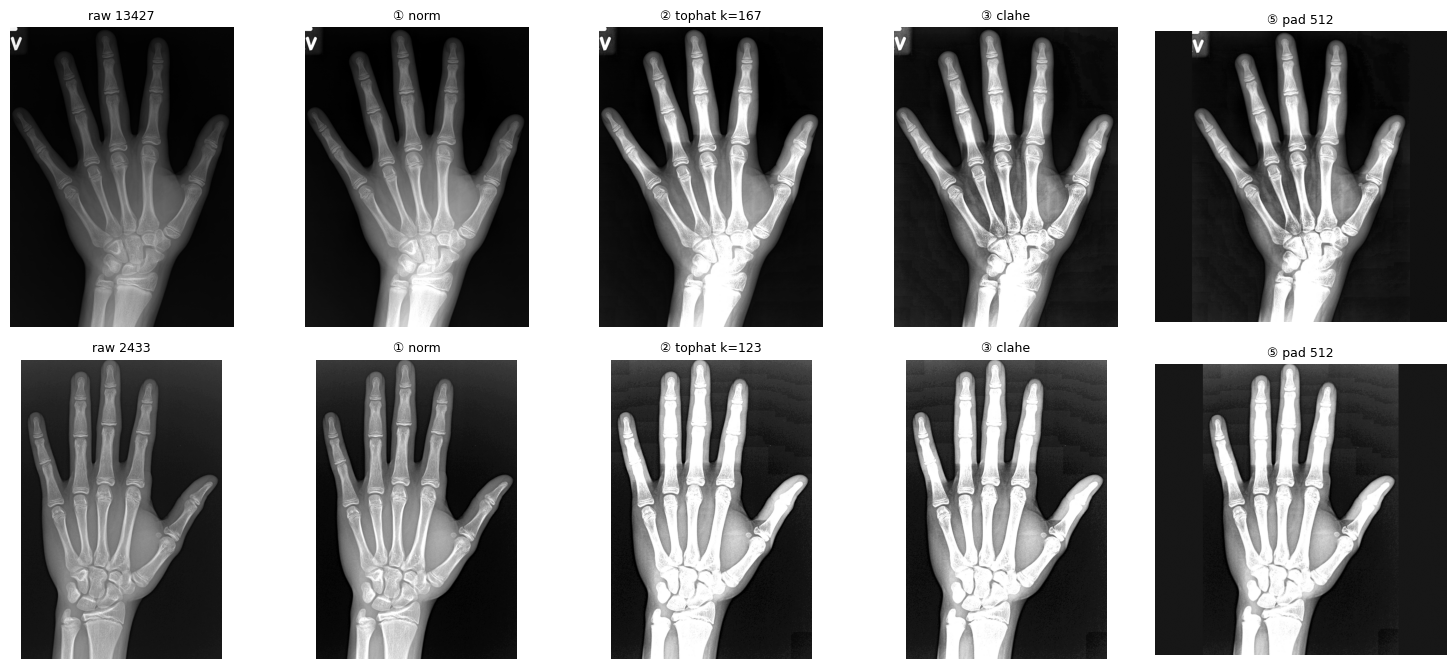

↑ ② tophat 패널에서 굵은 중수골 속이 찬 채로 밝게 남아야 정상. 윤곽선만 남으면 TOPHAT_KFRAC을 0.12~0.15로 올리세요.


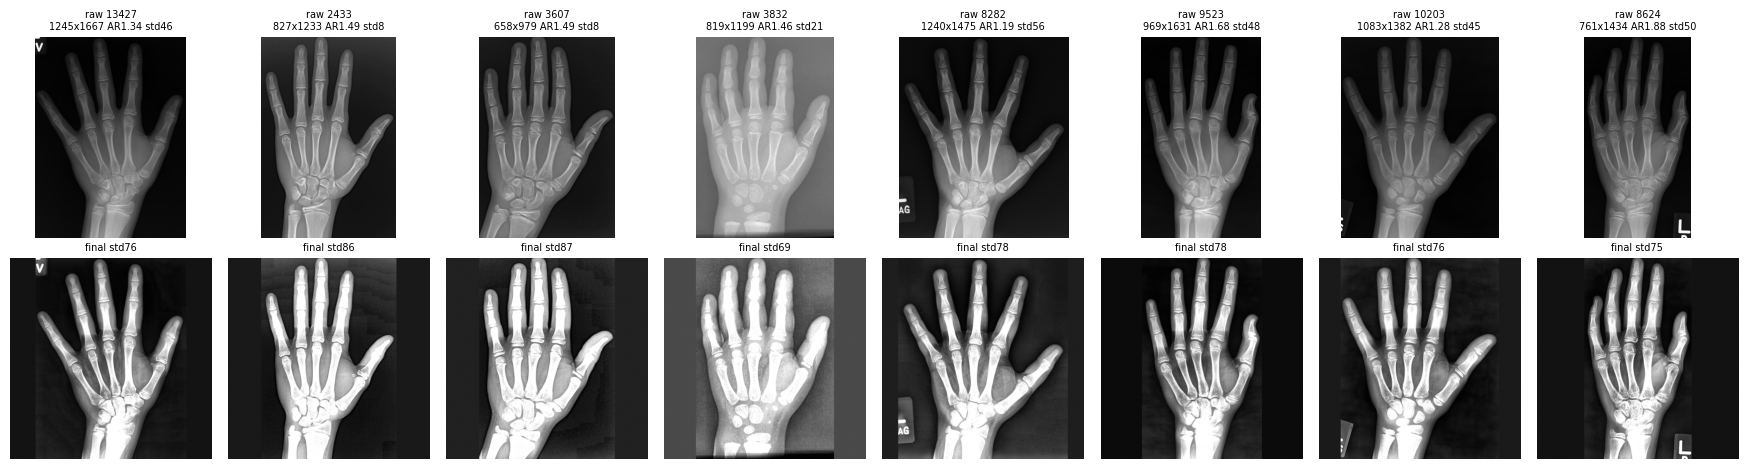

      id |       원본크기 |   AR |   원본std |   후std |   TH커널 |    배율 |    여백% |   pad값 |   배경p25
   13427 | 1245x1667  | 1.34 |    46.1 |   75.8 |    167 | 0.307 | 25.4% |     19 |      19
    2433 |  827x1233  | 1.49 |     8.3 |   85.6 |    123 | 0.415 | 33.0% |     25 |      25
    3607 |  658x979   | 1.49 |     7.8 |   86.6 |     99 | 0.523 | 32.8% |     33 |      33
    3832 |  819x1199  | 1.46 |    20.7 |   68.9 |    121 | 0.427 | 31.6% |     74 |      74
    8282 | 1240x1475  | 1.19 |    55.8 |   78.0 |    149 | 0.347 | 16.0% |     30 |      30
    9523 |  969x1631  | 1.68 |    48.2 |   77.7 |    163 | 0.314 | 40.6% |     11 |      11
   10203 | 1083x1382  | 1.28 |    44.9 |   76.4 |    139 | 0.370 | 21.7% |     26 |      26
    8624 |  761x1434  | 1.88 |    50.2 |   75.3 |    143 | 0.357 | 46.9% |     18 |      18


In [10]:
N_QC    = 8         # 진단표에 넣을 장수 (16~24 권장)
N_STRIP = 2         # 단계별 스트립으로 볼 장수
QC_SEED = SEED

sample = train_df.sample(min(N_QC, len(train_df)), random_state=QC_SEED)

# ── (1) 단계별 스트립 — Top-Hat 커널 적정성 확인용 ──────────────────
strip = sample.head(N_STRIP)
fig, axes = plt.subplots(len(strip), 5, figsize=(15, 3.4*len(strip)))
axes = np.atleast_2d(axes)
for i, (_, r) in enumerate(strip.iterrows()):
    raw  = imread_kr(r["path"], cv2.IMREAD_GRAYSCALE)
    s1   = normalize_intensity(raw)
    s2, k = apply_tophat(s1, return_k=True)
    s3   = apply_clahe(s2)
    s5   = imread_kr(CACHE_DIR/"train"/f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
    for ax, (t, im) in zip(axes[i], [
            (f"raw {r['id']}", raw), ("① norm", s1),
            (f"② tophat k={k}", s2), ("③ clahe", s3), (f"⑤ pad {IMG_SIZE}", s5)]):
        ax.imshow(im, cmap="gray"); ax.set_title(t, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()
print("↑ ② tophat 패널에서 굵은 중수골 속이 찬 채로 밝게 남아야 정상. "
      "윤곽선만 남으면 TOPHAT_KFRAC을 0.12~0.15로 올리세요.")

# ── (2) 원본 vs 최종 대조 ──────────────────────────────────────────
cols = min(8, len(sample)); rows = int(np.ceil(len(sample) / cols))
fig, axes = plt.subplots(rows*2, cols, figsize=(2.2*cols, 4.8*rows))
axes = np.atleast_2d(axes)
for j, (_, r) in enumerate(sample.iterrows()):
    rr, cc = (j // cols) * 2, j % cols
    raw = imread_kr(r["path"], cv2.IMREAD_GRAYSCALE)
    pre = imread_kr(CACHE_DIR/"train"/f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
    axes[rr,   cc].imshow(raw, cmap="gray")
    axes[rr,   cc].set_title(f"raw {r['id']}\n{raw.shape[1]}x{raw.shape[0]} AR{raw.shape[0]/raw.shape[1]:.2f}"
                             f" std{raw.std():.0f}", fontsize=7)
    axes[rr+1, cc].imshow(pre, cmap="gray", vmin=0, vmax=255)
    axes[rr+1, cc].set_title(f"final std{pre.std():.0f}", fontsize=7)
for ax in axes.ravel(): ax.axis("off")
plt.tight_layout(); plt.show()

# ── (3) 진단표 ────────────────────────────────────────────────────
print(f"{'id':>8} | {'원본크기':>10} | {'AR':>4} | {'원본std':>7} | {'후std':>6} | {'TH커널':>6} | "
      f"{'배율':>5} | {'여백%':>6} | {'pad값':>6} | {'배경p25':>7}")
for _, r in sample.iterrows():
    raw = imread_kr(r["path"], cv2.IMREAD_GRAYSCALE)
    pre, info = preprocess(raw, return_info=True)
    pv = info["pad_val"]; pv_s = "replic" if pv == -1 else str(pv)
    print(f"{r['id']:>8} | {raw.shape[1]:>4}x{raw.shape[0]:<5} | {raw.shape[0]/raw.shape[1]:>4.2f} | "
          f"{raw.std():>7.1f} | {pre.std():>6.1f} | {info['tophat_k']:>6} | {info['scale']:>5.3f} | "
          f"{info['pad_frac']:>5.1%} | {pv_s:>6} | {estimate_bg(pre):>7}")

---
# PART 2 · 학습 설정 ⚙️  *(하이퍼파라미터를 여기서 바꾸고, 이 파트부터 아래로 재실행)*

In [11]:
# ── 하이퍼파라미터 (여기만 바꿔 재실험) ───────────────────────────────
BATCH_SIZE     = 16       # OOM 시 8
EPOCHS         = 100      # 넉넉히 — 조기종료가 알아서 멈춤
LR             = 1e-4
WEIGHT_DECAY   = 1e-5
FREEZE_BACKBONE= False    # 미세조정(False)=최고성능 / 동결(True)=빠름·안정
NUM_WORKERS    = 0        # Windows+Jupyter 안전값(.py에선 4+ 권장)
USE_AMP        = True
RESUME         = False    # last.pt에서 이어서 학습하려면 True
EARLY_STOP_PATIENCE = 15  # 검증 MAE가 이 에폭 수만큼 개선 없으면 조기종료(<0이면 끔)
MIN_DELTA           = 0.01# 개선으로 인정할 최소 MAE 감소(개월)

# ── 모델 구조 (논문 §3.4 · 미명시 항목은 주석으로 표시) ────────────────
GENDER_EMB_DIM = 32       # 논문 명시 (식 15, k=32)
HEAD_RELU      = True     # 논문 미명시 — Conv3x3 뒤 활성함수 (기본 ReLU)
GENDER_RELU    = True     # 논문 미명시 — 성별 Dense 뒤 활성함수 (기본 ReLU)
# ──────────────────────────────────────────────────────────────────
# 참고) 타깃은 학습셋 통계로 z-정규화 후 L1 학습(논문 미명시 · 수렴 안정화용 가정).
#       평가·저장·추론은 모두 개월 단위로 환산되므로 MAE 해석은 논문과 동일합니다.

ARCH = {"GENDER_EMB_DIM": GENDER_EMB_DIM, "HEAD_RELU": HEAD_RELU, "GENDER_RELU": GENDER_RELU,
        "BACKBONE": "xception", "IMG_SIZE": IMG_SIZE,
        "PREPROCESS": "norm_tophat_clahe_letterbox", "CROP_MODE": "external_bbox",
        "NORM_MODE": NORM_MODE, "NORM_LO": NORM_LO, "NORM_HI": NORM_HI,
        "TOPHAT_MODE": TOPHAT_MODE, "TOPHAT_KFRAC": TOPHAT_KFRAC,
        "TOPHAT_KSIZE": TOPHAT_KSIZE, "TOPHAT_SHAPE": TOPHAT_SHAPE,
        "TOPHAT_WEIGHT": TOPHAT_WEIGHT,
        "CLAHE_CLIP": CLAHE_CLIP, "CLAHE_TILE": CLAHE_TILE,
        "SCALE_MODE": SCALE_MODE, "REF_LONG": REF_LONG, "GLOBAL_REF_PCTL": GLOBAL_REF_PCTL,
        "PAD_MODE": PAD_MODE, "PAD_ANCHOR": PAD_ANCHOR,
        "PAD_BORDER_FRAC": PAD_BORDER_FRAC, "PAD_BORDER_PCTL": PAD_BORDER_PCTL,
        "USE_AUG": USE_AUG, "USE_EXCLUDE_IDS": USE_EXCLUDE_IDS}
print("설정:", json.dumps(ARCH, ensure_ascii=False))
print(f"batch {BATCH_SIZE} | epochs {EPOCHS} | lr {LR} | resume {RESUME}")

설정: {"GENDER_EMB_DIM": 32, "HEAD_RELU": true, "GENDER_RELU": true, "BACKBONE": "xception", "IMG_SIZE": 512, "PREPROCESS": "norm_tophat_clahe_letterbox", "CROP_MODE": "external_bbox", "NORM_MODE": "percentile", "NORM_LO": 1.0, "NORM_HI": 99.0, "TOPHAT_MODE": "add", "TOPHAT_KFRAC": 0.1, "TOPHAT_KSIZE": 0, "TOPHAT_SHAPE": "rect", "TOPHAT_WEIGHT": 1.0, "CLAHE_CLIP": 2.0, "CLAHE_TILE": 8, "SCALE_MODE": "per_image", "REF_LONG": null, "GLOBAL_REF_PCTL": 99.0, "PAD_MODE": "auto", "PAD_ANCHOR": "center", "PAD_BORDER_FRAC": 0.02, "PAD_BORDER_PCTL": 25.0, "USE_AUG": false, "USE_EXCLUDE_IDS": true}
batch 16 | epochs 100 | lr 0.0001 | resume False


In [12]:
# 데이터로더
train_loader = DataLoader(BoneAgeDataset(train_df, "train", train_tf),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(BoneAgeDataset(val_df, "val", eval_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(BoneAgeDataset(test_df, "test", eval_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) if len(test_df) else None
print("배치 수: train", len(train_loader), "| val", len(val_loader),
      "| test", (len(test_loader) if test_loader else 0))

배치 수: train 779 | val 87 | test 13


In [13]:
# 모델·옵티마이저·스케줄러 (RESUME이면 last.pt에서 복원)
model     = build_model(ARCH, pretrained=True, freeze=FREEZE_BACKBONE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", factor=0.5, patience=3)
scaler    = torch.amp.GradScaler("cuda", enabled=USE_AMP and torch.cuda.is_available())

if RESUME and LAST_CKPT.exists():
    ck = torch_load(LAST_CKPT, map_location=device)
    # 체크포인트 호환성 검사 — 구조가 다르면 조용히 망가지는 대신 즉시 알림
    bad = [k for k in ("IMG_SIZE","GENDER_EMB_DIM") if ck["arch"].get(k) != ARCH.get(k)]
    assert not bad, f"체크포인트 구조 불일치: {bad} — RESUME=False로 새로 학습하세요."
    model.load_state_dict(ck["model"]); optimizer.load_state_dict(ck["optimizer"])
    scheduler.load_state_dict(ck["scheduler"]); scaler.load_state_dict(ck["scaler"])
    start_epoch = ck["epoch"] + 1; best_val = ck["best_val"]; history = ck["history"]
    epochs_no_improve = ck.get("no_improve", 0)
    print(f"🔄 재개: epoch {start_epoch}부터 · best_val {best_val:.2f} · 개선정체 {epochs_no_improve}")
else:
    start_epoch, best_val, epochs_no_improve = 1, float("inf"), 0
    history = {"train_mae": [], "val_mae": []}
    print("🆕 새로 학습 시작")

n_params = sum(p.numel() for p in model.parameters())/1e6
print(f"파라미터 {n_params:.1f}M (논문 표4 ≈22.9M)")

[backbone] timm 'legacy_xception' 로드 완료 (pretrained=True)
[model] backbone out = 2048x16x16  ->  z dim = 6,400   (논문 9,216 = IMG_SIZE 608일 때)
[model] total params = 25.5M   (논문 표4: 22.9M)
🆕 새로 학습 시작
파라미터 25.5M (논문 표4 ≈22.9M)


---
# PART 3 · 학습  *(best 즉시 저장 · 조기 종료 · 중단 재개)*
- `best.pt`: 검증 MAE 최저 순간 저장 → PART 4가 이걸 로드
- `last.pt`: 매 에폭 저장(조기종료 카운터 포함) → `RESUME=True`로 재개
- Kernel 정지 버튼을 눌러도 `KeyboardInterrupt`를 잡아 `last.pt`를 남깁니다.

**기대치**: 크롭 없는 베이스라인이므로 크롭 버전(≈5.1개월)보다 **나쁘게 나오는 것이 정상**입니다. 그 차이가 곧 전처리의 기여분입니다.

In [14]:
criterion = nn.L1Loss()
AMP_ON = USE_AMP and torch.cuda.is_available()
best_epoch = start_epoch - epochs_no_improve   # best가 나온 에폭(로그용)
try:
    for epoch in range(start_epoch, EPOCHS + 1):
        model.train(); run_abs, seen = 0.0, 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS}")
        for x, g, yn, ym in pbar:
            x, g, yn = x.to(device), g.to(device), yn.to(device).squeeze(1)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=AMP_ON):
                pred = model(x, g); loss = criterion(pred, yn)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            run_abs += mae_months(pred, ym, AGE_MEAN, AGE_STD); seen += x.size(0)
            pbar.set_postfix(train_mae=f"{run_abs/seen:.2f}")

        tr_mae = run_abs / seen
        va_mae = evaluate(model, val_loader, AGE_MEAN, AGE_STD, AMP_ON)
        scheduler.step(va_mae)
        history["train_mae"].append(tr_mae); history["val_mae"].append(va_mae)

        # 개선 판정(MIN_DELTA 이상 감소해야 개선으로 인정)
        if va_mae < best_val - MIN_DELTA:
            best_val = va_mae; epochs_no_improve = 0; best_epoch = epoch
            save_checkpoint(BEST_CKPT, model, ARCH, AGE_MEAN, AGE_STD, best_val=best_val)
            flag = f"✔ best 저장 (val {best_val:.2f})"
        else:
            epochs_no_improve += 1
            flag = f"개선 없음 {epochs_no_improve}/{EARLY_STOP_PATIENCE}"
        print(f"  → train {tr_mae:.2f} · val {va_mae:.2f} · lr {optimizer.param_groups[0]['lr']:.1e} · {flag}")

        # 매 에폭 last 저장(조기종료 카운터 포함) + history 저장
        save_checkpoint(LAST_CKPT, model, ARCH, AGE_MEAN, AGE_STD,
                        optimizer, scheduler, scaler, epoch, best_val, history,
                        no_improve=epochs_no_improve)
        json.dump(history, open(HISTORY_JSON, "w"))

        # 조기 종료 (EARLY_STOP_PATIENCE < 0 이면 비활성)
        if EARLY_STOP_PATIENCE >= 0 and epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f"\n⏹ 조기 종료: {EARLY_STOP_PATIENCE}에폭 연속 개선 없음 "
                  f"· 최고 MAE {best_val:.2f} @ epoch {best_epoch}")
            break
    else:
        print(f"\n🏁 정상 종료(전체 {EPOCHS}에폭) · 최고 검증 MAE {best_val:.2f} @ epoch {best_epoch}")
except KeyboardInterrupt:
    save_checkpoint(LAST_CKPT, model, ARCH, AGE_MEAN, AGE_STD,
                    optimizer, scheduler, scaler, epoch, best_val, history,
                    no_improve=epochs_no_improve)
    json.dump(history, open(HISTORY_JSON, "w"))
    print(f"\n⏸ 중단 감지 — last.pt 저장(epoch {epoch}). PART 2에서 RESUME=True로 재개하세요.")

Epoch 01/100:   0%|          | 0/779 [00:00<?, ?it/s]

  → train 12.35 · val 9.11 · lr 1.0e-04 · ✔ best 저장 (val 9.11)


Epoch 02/100:   0%|          | 0/779 [00:00<?, ?it/s]

  → train 8.22 · val 8.07 · lr 1.0e-04 · ✔ best 저장 (val 8.07)


Epoch 03/100:   0%|          | 0/779 [00:00<?, ?it/s]

...

  → train 0.45 · val 6.77 · lr 3.1e-06 · 개선 없음 13/15


Epoch 37/100:   0%|          | 0/779 [00:00<?, ?it/s]

  → train 0.43 · val 6.77 · lr 3.1e-06 · 개선 없음 14/15


Epoch 38/100:   0%|          | 0/779 [00:00<?, ?it/s]

  → train 0.42 · val 6.78 · lr 3.1e-06 · 개선 없음 15/15

⏹ 조기 종료: 15에폭 연속 개선 없음 · 최고 MAE 6.76 @ epoch 23


---
# PART 4 · 평가·설명·추론  *(학습 없이 저장된 best.pt만 로드 — 다른 사람도 이 파트만 실행 가능)*
> 이 셀을 먼저 실행하면 `eval_model`이 준비됩니다. 단일 이미지 추론(맨 아래)은 `best.pt` + 이미지 1장이면 됩니다.

In [15]:
assert BEST_CKPT.exists(), "best.pt 없음 — PART 3을 먼저 실행하거나 체크포인트를 받아 checkpoints 폴더에 두세요."
ck = torch_load(BEST_CKPT, map_location=device)
eval_model = build_model(ck["arch"], pretrained=False)
eval_model.load_state_dict(ck["model"]); eval_model.eval()
EM_MEAN, EM_STD, EM_IMG = ck["age_mean"], ck["age_std"], ck["arch"]["IMG_SIZE"]
print(f"✅ best.pt 로드 완료 · 정규화 {EM_MEAN:.1f}±{EM_STD:.1f} · IMG {EM_IMG}")
print(f"   전처리 = {ck['arch'].get('PREPROCESS')} · best val MAE {ck.get('best_val', float('nan')):.2f}")

[backbone] timm 'legacy_xception' 로드 완료 (pretrained=False)
[model] backbone out = 2048x16x16  ->  z dim = 6,400   (논문 9,216 = IMG_SIZE 608일 때)
[model] total params = 25.5M   (논문 표4: 22.9M)
✅ best.pt 로드 완료 · 정규화 127.6±40.9 · IMG 512
   전처리 = norm_tophat_clahe_letterbox · best val MAE 6.76


### 4-1. 학습 곡선 (history.json 로드)

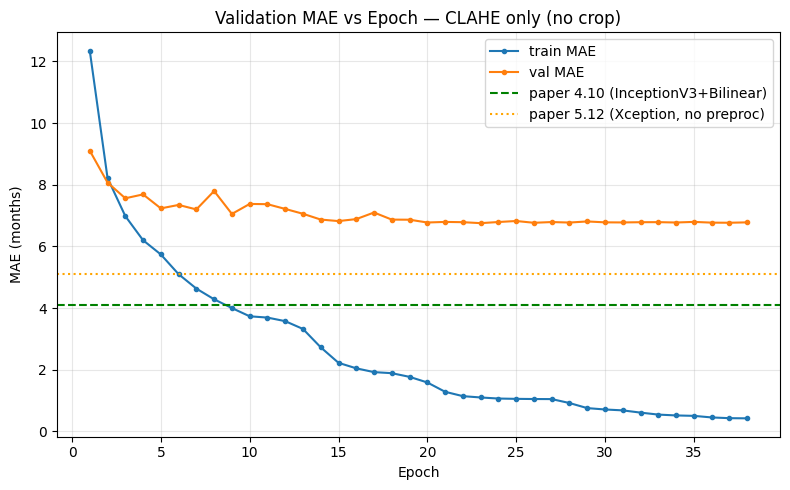

최저 검증 MAE = 6.76 @ epoch 23


In [16]:
hist = json.load(open(HISTORY_JSON)) if HISTORY_JSON.exists() else history
ep = range(1, len(hist["train_mae"]) + 1)
plt.figure(figsize=(8, 5))
plt.plot(ep, hist["train_mae"], "-o", ms=3, label="train MAE")
plt.plot(ep, hist["val_mae"],   "-o", ms=3, label="val MAE")
plt.axhline(4.10, ls="--", c="green", label="paper 4.10 (InceptionV3+Bilinear)")
plt.axhline(5.12, ls=":",  c="orange", label="paper 5.12 (Xception, no preproc)")
plt.xlabel("Epoch"); plt.ylabel("MAE (months)")
plt.title("Validation MAE vs Epoch — CLAHE only (no crop)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print(f"최저 검증 MAE = {min(hist['val_mae']):.2f} @ epoch {int(np.argmin(hist['val_mae']))+1}")

### 4-2. 검증셋 예측 · 산점도 · 연령대별 MAE

predict:   0%|          | 0/87 [00:00<?, ?it/s]

전체 검증 MAE 6.76 · RMSE 9.16 개월 · 편향 +0.50


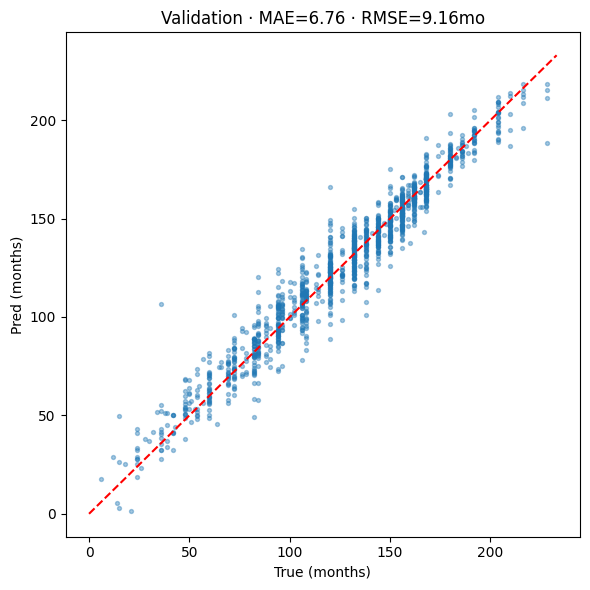

  group |    N |   MAE |   bias
   0-4y |   46 | 10.02 |  +6.42
   4-8y |  280 |  7.75 |  +3.07
  8-12y |  451 |  7.72 |  +1.15
 12-16y |  549 |  5.21 |  -1.38
   >16y |   60 |  6.60 |  -3.77


In [17]:
# PART 2를 안 돌렸어도 독립 실행되도록 val_loader를 여기서 구성
_val_loader = DataLoader(BoneAgeDataset(val_df, "val", eval_tf),
    batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

preds, trues = [], []
with torch.no_grad():
    for x, g, yn, ym in tqdm(_val_loader, desc="predict"):
        x, g = x.to(device), g.to(device)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            p = eval_model(x, g)
        preds.append(p.cpu()*EM_STD + EM_MEAN); trues.append(ym.squeeze(1))
preds = torch.cat(preds).numpy(); trues = torch.cat(trues).numpy()

overall  = np.abs(preds - trues).mean()
val_rmse = np.sqrt(np.mean((preds - trues)**2))
print(f"전체 검증 MAE {overall:.2f} · RMSE {val_rmse:.2f} 개월 · 편향 {np.mean(preds-trues):+.2f}")

plt.figure(figsize=(6, 6)); plt.scatter(trues, preds, s=8, alpha=.4)
lim = [0, max(trues.max(), preds.max())+5]; plt.plot(lim, lim, "r--")
plt.xlabel("True (months)"); plt.ylabel("Pred (months)")
plt.title(f"Validation · MAE={overall:.2f} · RMSE={val_rmse:.2f}mo"); plt.tight_layout(); plt.show()

bins, labels = [0,48,96,144,192,10**5], ["0-4y","4-8y","8-12y","12-16y",">16y"]
print(f"{'group':>7} | {'N':>4} | {'MAE':>5} | {'bias':>6}")
for lo, hi, lab in zip(bins[:-1], bins[1:], labels):
    m = (trues>=lo) & (trues<hi)
    if m.sum(): print(f"{lab:>7} | {m.sum():>4} | {np.abs(preds[m]-trues[m]).mean():>5.2f} | {np.mean(preds[m]-trues[m]):>+6.2f}")

### 4-3. 최종 테스트셋 평가 — MAE / RMSE
학습에 전혀 쓰지 않은 **test 세트**로 최종 성능을 측정합니다.
`USE_EXCLUDE_IDS=False`이므로 **필터링 없는 정직한 수치**입니다 — 이전 노트북(필터 적용)과 비교할 때 이 차이를 반드시 명시하세요.

test:   0%|          | 0/13 [00:00<?, ?it/s]

  전처리     = CLAHE only (crop 없음) · 512px
  TEST  MAE  =  5.20 개월
  TEST  RMSE =  6.73 개월
  TEST  bias = +1.72 개월   (N=195)


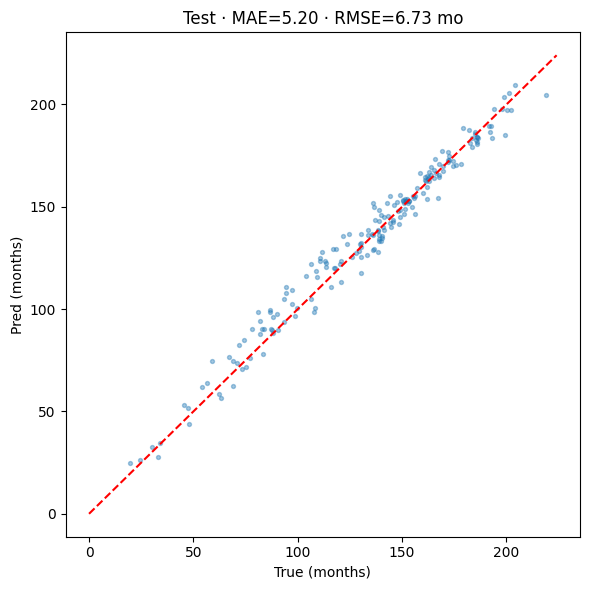

  group |    N |   MAE |  RMSE |   bias
   0-4y |    8 |  3.81 |  4.35 |  +1.56
   4-8y |   33 |  7.57 |  8.98 |  +5.78
  8-12y |   64 |  6.38 |  7.85 |  +2.71
 12-16y |   79 |  3.25 |  4.26 |  -0.16
   >16y |   11 |  6.20 |  7.60 |  -2.69


NameError: name 'RESIZE_MODE' is not defined

In [18]:
assert test_loader is not None and len(test_df), \
    "test 세트가 없습니다 — 셀 0-3의 TEST_IMG_DIR / TEST_CSV 경로를 확인하고 PART 1을 다시 실행하세요."

t_preds, t_trues = [], []
with torch.no_grad():
    for x, g, yn, ym in tqdm(test_loader, desc="test"):
        x, g = x.to(device), g.to(device)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            p = eval_model(x, g)
        t_preds.append(p.cpu()*EM_STD + EM_MEAN); t_trues.append(ym.squeeze(1))
t_preds = torch.cat(t_preds).numpy(); t_trues = torch.cat(t_trues).numpy()

test_mae  = np.abs(t_preds - t_trues).mean()
test_rmse = np.sqrt(np.mean((t_preds - t_trues)**2))
test_bias = float(np.mean(t_preds - t_trues))
print("="*52)
print(f"  전처리     = CLAHE only (crop 없음) · {IMG_SIZE}px")
print(f"  TEST  MAE  = {test_mae:5.2f} 개월")
print(f"  TEST  RMSE = {test_rmse:5.2f} 개월")
print(f"  TEST  bias = {test_bias:+5.2f} 개월   (N={len(t_trues)})")
print("="*52)

plt.figure(figsize=(6, 6)); plt.scatter(t_trues, t_preds, s=8, alpha=.4)
lim = [0, max(t_trues.max(), t_preds.max())+5]; plt.plot(lim, lim, "r--")
plt.xlabel("True (months)"); plt.ylabel("Pred (months)")
plt.title(f"Test · MAE={test_mae:.2f} · RMSE={test_rmse:.2f} mo")
plt.tight_layout(); plt.show()

bins, labels = [0,48,96,144,192,10**5], ["0-4y","4-8y","8-12y","12-16y",">16y"]
print(f"{'group':>7} | {'N':>4} | {'MAE':>5} | {'RMSE':>5} | {'bias':>6}")
for lo, hi, lab in zip(bins[:-1], bins[1:], labels):
    m = (t_trues>=lo) & (t_trues<hi)
    if m.sum():
        mae_g  = np.abs(t_preds[m]-t_trues[m]).mean()
        rmse_g = np.sqrt(np.mean((t_preds[m]-t_trues[m])**2))
        print(f"{lab:>7} | {m.sum():>4} | {mae_g:>5.2f} | {rmse_g:>5.2f} | {np.mean(t_preds[m]-t_trues[m]):>+6.2f}")

# 결과를 JSON으로 남겨 다른 전처리 설정과 표로 비교하기 쉽게
res = {"preprocess": "clahe_only", "img_size": IMG_SIZE, "clahe_clip": CLAHE_CLIP,
       "clahe_tile": CLAHE_TILE, "resize_mode": RESIZE_MODE,
       "use_exclude_ids": USE_EXCLUDE_IDS,
       "val_best_mae": float(ck.get("best_val", float("nan"))),
       "test_mae": float(test_mae), "test_rmse": float(test_rmse),
       "test_bias": test_bias, "n_test": int(len(t_trues))}
json.dump(res, open(CKPT_DIR/"result_summary.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=2)
print("\n결과 요약 저장:", CKPT_DIR/"result_summary.json")

### 4-4. Grad-CAM — **전처리 없음이 왜 불리한지 눈으로 확인**
크롭을 하지 않았으므로, 모델의 관심이 손가락·손목 성장판이 아니라 **프레임·문자마커·여백**으로 새는지 확인할 수 있습니다.
여기서 엉뚱한 곳이 밝다면 그것이 곧 크롭 전처리를 정당화하는 증거입니다.

In [ ]:
def _pick_cam_layer(backbone):
    '''Xception 백본에서 Grad-CAM 대상 레이어를 자동 선택 (없으면 백본 전체).'''
    mods = dict(backbone.named_modules())
    for name in ("act4", "bn4", "conv4", "block12"):
        if name in mods:
            return mods[name], name
    return backbone, "backbone(output)"

class GradCAM:
    '''백본 마지막 특징맵 기준 Grad-CAM (회귀 출력).'''
    def __init__(self, model):
        self.model = model; self.feat = self.grad = None
        tgt, name = _pick_cam_layer(model.backbone)
        print(f"[Grad-CAM] target layer = {name}")
        tgt.register_forward_hook(lambda m,i,o: setattr(self, "feat", o.detach()))
        tgt.register_full_backward_hook(lambda m,gi,go: setattr(self, "grad", go[0].detach()))
    def __call__(self, x, g):
        self.model.eval(); out = self.model(x, g); self.model.zero_grad(); out.sum().backward()
        w = self.grad.mean(dim=(2,3), keepdim=True)
        cam = F.relu((w*self.feat).sum(1))[0]
        cam = (cam-cam.min())/(cam.max()-cam.min()+1e-8)
        return cam.cpu().numpy(), out.item()

cam_engine = GradCAM(eval_model)
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, (_, r) in zip(axes, val_df.sample(4, random_state=1).iterrows()):
    g = imread_kr(CACHE_DIR/"val"/f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
    x = eval_tf(np.stack([g]*3, -1)).unsqueeze(0).to(device)
    gd = torch.tensor([[r["male"]]], dtype=torch.float32, device=device)
    cam, pn = cam_engine(x, gd); pred_month = pn*EM_STD + EM_MEAN
    heat = cv2.applyColorMap(np.uint8(255*cv2.resize(cam,(EM_IMG,EM_IMG))), cv2.COLORMAP_JET)
    over = cv2.addWeighted(cv2.cvtColor(g, cv2.COLOR_GRAY2BGR), 0.55, heat, 0.45, 0)
    ax.imshow(cv2.cvtColor(over, cv2.COLOR_BGR2RGB))
    ax.set_title(f"pred {pred_month:.0f}/true {int(r.boneage)}mo"); ax.axis("off")
plt.tight_layout(); plt.show()

### 4-5. 단일 이미지 추론 (완전 독립 — best.pt + 이미지 1장이면 끝)
전처리 상수(CLAHE 파라미터·리사이즈 방식)를 **체크포인트에서 읽어** 학습 때와 동일한 처리를 보장합니다.

In [ ]:
def predict_bone_age(image_path, is_male, ckpt_path=BEST_CKPT):
    """bbox 크롭된 X-ray 경로 + 성별(True=남) -> 골연령(개월).
       전처리 4단계 설정과 정규화 상수를 모두 체크포인트에서 읽어 학습과 동일하게 재현합니다."""
    ck = torch_load(ckpt_path, map_location=device)
    a  = ck["arch"]
    m  = build_model(a, pretrained=False); m.load_state_dict(ck["model"]); m.eval()
    g = imread_kr(image_path, cv2.IMREAD_GRAYSCALE)
    if g is None: raise FileNotFoundError(image_path)
    pre = preprocess(g,
                     size       = a["IMG_SIZE"],
                     norm_mode  = a.get("NORM_MODE", "percentile"),
                     norm_lo    = a.get("NORM_LO", 1.0),
                     norm_hi    = a.get("NORM_HI", 99.0),
                     th_mode    = a.get("TOPHAT_MODE", "add"),
                     th_kfrac   = a.get("TOPHAT_KFRAC", 0.10),
                     th_ksize   = a.get("TOPHAT_KSIZE", 0),
                     th_shape   = a.get("TOPHAT_SHAPE", "rect"),
                     th_weight  = a.get("TOPHAT_WEIGHT", 1.0),
                     clip       = a.get("CLAHE_CLIP", 2.0),
                     tile       = a.get("CLAHE_TILE", 8),
                     scale_mode = a.get("SCALE_MODE", "per_image"),
                     ref_long   = a.get("REF_LONG"),           # global 모드 재현용
                     pad_mode   = a.get("PAD_MODE", "auto"),
                     anchor     = a.get("PAD_ANCHOR", "center"),
                     frac       = a.get("PAD_BORDER_FRAC", 0.02),
                     pctl       = a.get("PAD_BORDER_PCTL", 25.0))
    x  = eval_tf(np.stack([pre]*3, -1)).unsqueeze(0).to(device)
    gd = torch.tensor([[float(is_male)]], dtype=torch.float32, device=device)
    with torch.no_grad(), torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
        pn = m(x, gd).item()
    return pn * ck["age_std"] + ck["age_mean"]

# 예시:
# months = predict_bone_age(VAL_IMG_DIR / "1386.png", is_male=True)
# print(f"예측 골연령: {months:.1f} 개월 ({months/12:.1f}세)")
print("추론 함수 준비 완료 · best.pt:", BEST_CKPT)